# Cross-Condition Network Analysis: CWL vs. BWL

**Purpose:** This notebook implements a correlation-based network analysis
comparing two experimental conditions (CWL and BWL) on 7 psychological
construct nodes across 4 subsystems. Between-condition differences in
global network metrics, node strength, and edge weights are tested using
sign-flip permutation inference (10,000 permutations) with FDR correction.

**Pipeline Overview:**
1. Load paired repeated-measures data
2. Construct weighted networks via thresholded Spearman correlations
3. Compute global and node-level network metrics for each condition
4. Run sign-flip permutation tests for all between-condition differences
5. Visualize networks, dissociation patterns, and rank changes
6. Export all statistical tables

**Requirements:** See `requirements.txt`. Core dependencies are
`numpy`, `pandas`, `networkx`, `scipy`, `statsmodels`, `matplotlib`,
`joblib`, and `tqdm`.

**How to Run:** Place your data file in `./data/CAN.xlsx`, then run
all cells sequentially from top to bottom.

In [1]:
# ============================================================
#  Cell 1 — CONFIGURATION
#  All adjustable parameters are centralised here.
#  Modify this cell only; downstream cells reference these values.
#  ── Maps to: Methods §2.2 (nodes), §2.3 (thresholds), §2.5 (permutations)
# ============================================================

from pathlib import Path

# ── File Paths ──────────────────────────────────────────────
DATA_FILE  = Path("data/CAN.xlsx")
SHEET_NAME = "Sheet1"

EXPORT_DIR = Path("./output")
FIG_DIR    = EXPORT_DIR / "figures"
TAB_DIR    = EXPORT_DIR / "tables"

# ── Study Design (§2.1) ────────────────────────────────────
CONDITION_COL = "order"
COND1, COND2  = "1", "2"           # 1 = CWL, 2 = BWL
COND1_LABEL   = "CWL"
COND2_LABEL   = "BWL"

# ── Network Nodes (§2.2, Table 1) ──────────────────────────
NODE_COLS = [
    "A1", "A2", "A3",   # ANS
    "B1", "B2",          # CNS
    "C1",                # VS
    "D1",                # NMS
]

SUBSYSTEM_COLORS = {
    "A": "#C1565E",      # ANS
    "B": "#A8CBDF",      # CNS
    "C": "#73A5A2",      # VS
    "D": "#8074C8",      # NMS
}

# ── Statistical Parameters (§2.3, §2.5) ────────────────────
CORR_METHOD = "spearman"
EDGE_ALPHA  = 0.05
ALPHA       = 0.05
N_PERM      = 10000
RANDOM_SEED = 20260327
N_JOBS      = -1

# ── Univariate p-values from the original study (Jiang et al., 2025)
#    These are NOT produced by the network analysis; they are
#    included for contextual display in summary tables only.
UNIVARIATE_P = {
    "A1":  0.588,
    "A2":  0.050,
    "A3":  0.263,
    "B1":  0.035,
    "B2":  0.024,
    "C1":  0.004,
    "D1":  0.0001,
}

# ── Figure Aesthetics ───────────────────────────────────────
FIG_DPI          = 600
FIG_FORMAT       = "png"
FONT_FAMILY      = ["Arial", "Helvetica", "DejaVu Sans"]
NODE_SIZE_RANGE  = (700, 2600)
EDGE_WIDTH_RANGE = (0.8, 5.0)
EDGE_COLOR       = "#3C5488"
EDGE_HALO_COLOR  = "#D0D7E5"
SIG_HIGHLIGHT    = "#ffcccc"

# ── Small-world (supplementary / descriptive only) ─────────
SW_N_RAND = 100
SW_SEED   = 42

print("✅ Configuration loaded.")

✅ Configuration loaded.


## Data Loading & Validation

In [2]:
# ============================================================
#  Cell 2 — IMPORTS & DATA LOADING
#  ── Maps to: Methods §2.1 (data source), §2.6 (environment)
# ============================================================

import os
import warnings
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr, ConstantInputWarning
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

for d in [FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "pdf.fonttype":    42,
    "ps.fonttype":     42,
    "font.family":     "sans-serif",
    "font.sans-serif": FONT_FAMILY,
})

# ── Load data ───────────────────────────────────────────────
df_raw = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)
df_raw[CONDITION_COL] = df_raw[CONDITION_COL].astype(str).str.strip().str.lower()

if "name" in df_raw.columns:
    df_raw["subject_id"] = df_raw["name"]
else:
    df_raw["subject_id"] = df_raw.groupby(CONDITION_COL).cumcount() + 1
    print("⚠ No 'name' column found; subjects paired by row position.")

found_conds = set(df_raw[CONDITION_COL].unique())
assert {COND1, COND2} <= found_conds, \
    f"Data must contain conditions {COND1} and {COND2}, found {found_conds}"

df = df_raw.loc[df_raw[CONDITION_COL].isin({COND1, COND2})].copy()

n_c1 = df.loc[df[CONDITION_COL] == COND1, "subject_id"].nunique()
n_c2 = df.loc[df[CONDITION_COL] == COND2, "subject_id"].nunique()
assert n_c1 == n_c2, f"Group size mismatch: {COND1}={n_c1}, {COND2}={n_c2}"

missing = [c for c in NODE_COLS if c not in df.columns]
assert not missing, f"Missing node columns in data: {missing}"

print(f"✅ Data loaded: {n_c1} subjects × 2 conditions × {len(NODE_COLS)} nodes")
print(f"   Correlation: {CORR_METHOD}  |  Edge threshold: p < {EDGE_ALPHA}  |  Permutations: {N_PERM:,}")

✅ Data loaded: 24 subjects × 2 conditions × 7 nodes
   Correlation: spearman  |  Edge threshold: p < 0.05  |  Permutations: 10,000


## Core Functions: Network Construction, Metrics & Permutation Engine

In [3]:
# ============================================================
#  Cell 3 — FUNCTION DEFINITIONS
#  ── Maps to: Methods §2.3 (network construction),
#              §2.4 (metrics), §2.5 (inference)
# ============================================================

# ── 3.1  Prepare paired data (§2.1) ────────────────────────

def prepare_paired(df, node_cols):
    """Align paired subjects across two conditions."""
    d1 = (df.loc[df[CONDITION_COL] == COND1, ["subject_id"] + node_cols]
            .sort_values("subject_id").reset_index(drop=True))
    d2 = (df.loc[df[CONDITION_COL] == COND2, ["subject_id"] + node_cols]
            .sort_values("subject_id").reset_index(drop=True))
    assert len(d1) == len(d2), "Group sizes differ after filtering"
    assert d1["subject_id"].equals(d2["subject_id"]), \
        "Subject IDs do not align between conditions"
    return d1[node_cols].copy(), d2[node_cols].copy()


# ── 3.2  Adjacency matrix (§2.3) ───────────────────────────

def compute_adjacency(df_num, method=CORR_METHOD, alpha=EDGE_ALPHA):
    """
    Compute pairwise correlations; retain edges with p < alpha.
    Returns absolute-value and signed adjacency matrices.
    """
    cols = list(df_num.columns)
    n = len(cols)
    adj_abs    = pd.DataFrame(0.0, index=cols, columns=cols)
    adj_signed = pd.DataFrame(0.0, index=cols, columns=cols)

    for i in range(n):
        for j in range(i + 1, n):
            sub = df_num.iloc[:, [i, j]].dropna()
            if (len(sub) < 3
                    or sub.iloc[:, 0].nunique() < 2
                    or sub.iloc[:, 1].nunique() < 2):
                r, p = 0.0, 1.0
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", ConstantInputWarning)
                    if method == "pearson":
                        r, p = pearsonr(sub.iloc[:, 0], sub.iloc[:, 1])
                    else:
                        r, p = spearmanr(sub.iloc[:, 0], sub.iloc[:, 1])
            if not np.isfinite(r):
                r, p = 0.0, 1.0
            if p < alpha:
                adj_abs.iat[i, j]    = adj_abs.iat[j, i]    = abs(r)
                adj_signed.iat[i, j] = adj_signed.iat[j, i] = r

    return adj_abs, adj_signed


# ── 3.3  Build NetworkX graph (§2.3) ──────────────────────

def adj_to_graph(adj_abs, adj_signed=None):
    """Convert adjacency matrix to a weighted undirected graph."""
    G = nx.Graph()
    cols = list(adj_abs.columns)
    G.add_nodes_from(cols)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            w = float(adj_abs.iat[i, j])
            if w > 0:
                sw = float(adj_signed.iat[i, j]) if adj_signed is not None else w
                G.add_edge(cols[i], cols[j],
                           weight=w, signed_weight=sw, distance=1.0 / w)
    return G


# ── 3.4  Global network metrics (§2.4) ────────────────────

GLOBAL_NAMES = [
    "density",
    "avg_abs_weight",
    "global_efficiency",
    "avg_path_length",
    "avg_clustering",
    "modularity",
]


def weighted_global_efficiency(G):
    """Inverse-distance global efficiency for weighted graphs."""
    n = G.number_of_nodes()
    if n < 2 or G.number_of_edges() == 0:
        return 0.0
    sp = dict(nx.all_pairs_dijkstra_path_length(G, weight="distance"))
    total = sum(
        1.0 / d
        for u in G.nodes()
        for v, d in sp.get(u, {}).items()
        if v != u and np.isfinite(d) and d > 0
    )
    return total / (n * (n - 1))


def compute_global(G):
    """Compute the six primary global network metrics (§2.4)."""
    n = G.number_of_nodes()
    max_edges = n * (n - 1) / 2 if n > 1 else 1
    weights = [d["weight"] for _, _, d in G.edges(data=True)]

    # Subsystem-based modularity (prior partition, §2.4)
    communities = []
    for prefix in sorted(SUBSYSTEM_COLORS.keys()):
        comm = {nd for nd in G.nodes() if nd.startswith(prefix)}
        if comm:
            communities.append(comm)
    try:
        mod = nx.community.modularity(G, communities, weight="weight")
    except Exception:
        mod = np.nan

    if nx.is_connected(G) and G.number_of_edges() > 0:
        avg_pl = nx.average_shortest_path_length(G, weight="distance")
    else:
        avg_pl = np.nan

    return pd.Series({
        "density":           G.number_of_edges() / max_edges,
        "avg_abs_weight":    float(np.mean(weights)) if weights else 0.0,
        "global_efficiency": weighted_global_efficiency(G),
        "avg_path_length":   avg_pl,
        "avg_clustering":    (nx.average_clustering(G, weight="weight")
                              if G.number_of_edges() > 0 else 0.0),
        "modularity":        mod,
    })


# ── 3.5  Node metrics — strength (§2.4) ──────────────────

NODE_METRIC_NAMES = ["strength"]


def compute_node_metrics(G, node_cols):
    """Compute node-level metrics; currently strength only."""
    strength = pd.Series(0.0, index=node_cols)
    for nd, val in G.degree(weight="weight"):
        if nd in strength.index:
            strength[nd] = float(val)
    return {"strength": strength}


# ── 3.6  Edge weight extraction ────────────────────────────

def edge_weight_matrix(G, node_cols, attr="weight"):
    """Extract a node × node weight matrix from graph."""
    n = len(node_cols)
    idx = {c: i for i, c in enumerate(node_cols)}
    W = np.zeros((n, n))
    for u, v, d in G.edges(data=True):
        i, j = idx.get(u), idx.get(v)
        if i is not None and j is not None:
            W[i, j] = W[j, i] = d.get(attr, d["weight"])
    return W


# ── 3.7  Analyse one condition ─────────────────────────────

def analyze_one(df_num, node_cols, method=CORR_METHOD, alpha=EDGE_ALPHA):
    """Full single-condition pipeline: adjacency → graph → metrics."""
    adj_abs, adj_signed = compute_adjacency(df_num[node_cols], method=method, alpha=alpha)
    G  = adj_to_graph(adj_abs, adj_signed)
    nm = compute_node_metrics(G, node_cols)
    return {
        "adj": adj_abs, "adj_signed": adj_signed,
        "graph": G, "global": compute_global(G),
        "node_metrics": nm, "strength": nm["strength"],
    }


# ── 3.8  Small-world (supplementary, descriptive) ─────────
#    NOTE: This analysis is NOT described in Methods §2.4.
#    It is included as supplementary descriptive information.

def compute_small_world(G, n_rand=SW_N_RAND, seed=SW_SEED):
    """
    Descriptive small-world indices (sigma, gamma, lambda)
    via weight-shuffled random graphs.
    Supplementary — not part of the primary analysis pipeline.
    """
    if not nx.is_connected(G) or G.number_of_edges() < 3:
        return {"sigma": np.nan, "gamma": np.nan, "lambda": np.nan}

    C_obs = nx.average_clustering(G, weight="weight")
    L_obs = nx.average_shortest_path_length(G, weight="distance")

    rng = np.random.default_rng(seed)
    rand_C, rand_L = [], []
    for _ in range(n_rand):
        Gr = G.copy()
        edges = list(Gr.edges(data=True))
        ws = [d["weight"] for _, _, d in edges]
        rng.shuffle(ws)
        for (u, v, d), w in zip(edges, ws):
            Gr[u][v]["weight"]   = w
            Gr[u][v]["distance"] = 1.0 / (w + 1e-10)
        if nx.is_connected(Gr):
            rand_C.append(nx.average_clustering(Gr, weight="weight"))
            rand_L.append(nx.average_shortest_path_length(Gr, weight="distance"))
    if not rand_C:
        return {"sigma": np.nan, "gamma": np.nan, "lambda": np.nan}

    gamma = C_obs / np.mean(rand_C)
    lam   = L_obs / np.mean(rand_L)
    sigma = gamma / lam if lam > 0 else np.nan
    return {"sigma": sigma, "gamma": gamma, "lambda": lam}


# ── 3.9  Single permutation iteration (§2.5.1) ───────────

def _one_perm(flip, v1, v2, node_cols, method, alpha):
    """Worker function for one sign-flip permutation."""
    p1, p2 = v1.copy(), v2.copy()
    if flip.any():
        p1[flip] = v2[flip]
        p2[flip] = v1[flip]
    d1 = pd.DataFrame(p1, columns=node_cols)
    d2 = pd.DataFrame(p2, columns=node_cols)
    r1 = analyze_one(d1, node_cols, method, alpha)
    r2 = analyze_one(d2, node_cols, method, alpha)

    g_diff = (r2["global"] - r1["global"]).values
    nm_diffs = {}
    for mn in NODE_METRIC_NAMES:
        nm_diffs[mn] = (r2["node_metrics"][mn].reindex(node_cols).values -
                        r1["node_metrics"][mn].reindex(node_cols).values)
    W1 = edge_weight_matrix(r1["graph"], node_cols)
    W2 = edge_weight_matrix(r2["graph"], node_cols)
    e_diff = W2 - W1
    return g_diff, nm_diffs, e_diff


# ── 3.10  FDR helper (§2.5.3) ────────────────────────────

def _add_fdr(df_in, p_col="p_perm", q_col="q_FDR"):
    """Append Benjamini–Hochberg FDR-corrected q-values."""
    df_out = df_in.copy()
    pvals = df_out[p_col].values.copy()
    mask  = np.isfinite(pvals)
    qvals = np.full_like(pvals, np.nan)
    if mask.sum() > 0:
        _, q, _, _ = multipletests(pvals[mask], method="fdr_bh")
        qvals[mask] = q
    df_out[q_col] = qvals
    return df_out


# ── 3.11  Subsystem-grouped edge weight comparison (§2.5.2)

def subsystem_edge_summary(edge_df):
    """
    §2.5.2: For all edges retained in at least one condition,
    group by subsystem pair and compute mean ± SD of Δ|w|.
    Descriptive only — no inferential testing.
    """
    active = edge_df.loc[
        (edge_df[COND1] > 0) | (edge_df[COND2] > 0)
    ].copy()
    if active.empty:
        return pd.DataFrame()

    def _pair_label(row):
        s1, s2 = row["node_i"][0], row["node_j"][0]
        return "–".join(sorted([s1, s2]))

    active["subsystem_pair"] = active.apply(_pair_label, axis=1)
    summary = (
        active.groupby("subsystem_pair")["diff"]
        .agg(n_edges="count", mean_delta="mean", sd_delta="std")
        .reset_index()
        .sort_values("subsystem_pair")
    )
    summary["sd_delta"] = summary["sd_delta"].fillna(0.0)
    return summary


# ── 3.12  Main analysis pipeline (§2.3–§2.5) ─────────────

def run_analysis(df, node_cols, method=CORR_METHOD,
                 n_perm=N_PERM, seed=RANDOM_SEED,
                 edge_alpha=EDGE_ALPHA):
    """
    Complete cross-condition network comparison with
    sign-flip permutation inference.
    """
    v1_df, v2_df = prepare_paired(df, node_cols)

    # Observed
    obs1 = analyze_one(v1_df, node_cols, method, edge_alpha)
    obs2 = analyze_one(v2_df, node_cols, method, edge_alpha)

    obs_g = obs2["global"] - obs1["global"]
    obs_nm = {mn: (obs2["node_metrics"][mn].reindex(node_cols) -
                   obs1["node_metrics"][mn].reindex(node_cols))
              for mn in NODE_METRIC_NAMES}

    obs_W1 = edge_weight_matrix(obs1["graph"], node_cols)
    obs_W2 = edge_weight_matrix(obs2["graph"], node_cols)
    obs_edge_diff = obs_W2 - obs_W1

    # Permutations (§2.5.1)
    rng   = np.random.default_rng(seed)
    flips = rng.random((n_perm, len(v1_df))) < 0.5
    v1, v2 = v1_df.values, v2_df.values

    t0 = time.time()
    print(f"  Running {n_perm:,} sign-flip permutations "
          f"({method}, {len(node_cols)} nodes, edge p < {edge_alpha}) …")

    results_raw = Parallel(n_jobs=N_JOBS)(
        delayed(_one_perm)(flips[b], v1, v2, node_cols, method, edge_alpha)
        for b in range(n_perm)
    )
    elapsed = time.time() - t0
    print(f"  ✓ Completed in {elapsed:.1f} s")

    # Unpack
    perm_g    = np.array([r[0] for r in results_raw])
    perm_nm   = {mn: np.array([r[1][mn] for r in results_raw])
                 for mn in NODE_METRIC_NAMES}
    perm_edge = np.array([r[2] for r in results_raw])
    n_nd = len(node_cols)

    # p-values: global
    obs_g_arr = obs_g.values
    p_g = np.full(len(GLOBAL_NAMES), np.nan)
    for k in range(len(GLOBAL_NAMES)):
        if np.isfinite(obs_g_arr[k]):
            cnt = np.nansum(np.abs(perm_g[:, k]) >= abs(obs_g_arr[k]))
            p_g[k] = (1 + cnt) / (n_perm + 1)

    # p-values: node metrics
    p_nm = {}
    for mn in NODE_METRIC_NAMES:
        p_nm[mn] = (1 + (np.abs(perm_nm[mn]) >=
                         np.abs(obs_nm[mn].values)).sum(axis=0)) / (n_perm + 1)

    # p-values: edges
    p_edge = np.ones((n_nd, n_nd))
    for i in range(n_nd):
        for j in range(i + 1, n_nd):
            obs_val = abs(obs_edge_diff[i, j])
            perm_vals = np.abs(perm_edge[:, i, j])
            p_edge[i, j] = p_edge[j, i] = \
                (1 + (perm_vals >= obs_val).sum()) / (n_perm + 1)

    # Assemble tables
    global_df = pd.DataFrame({
        "metric": GLOBAL_NAMES,
        COND1: obs1["global"].values,
        COND2: obs2["global"].values,
        "diff": obs_g.values,
        "p_perm": p_g,
    })
    global_df = _add_fdr(global_df)

    node_dfs = {}
    for mn in NODE_METRIC_NAMES:
        ndf = pd.DataFrame({
            "node": node_cols,
            COND1: obs1["node_metrics"][mn].reindex(node_cols).values,
            COND2: obs2["node_metrics"][mn].reindex(node_cols).values,
            "diff": obs_nm[mn].values,
            "p_perm": p_nm[mn],
        })
        node_dfs[mn] = ndf

    edge_records = []
    for i in range(n_nd):
        for j in range(i + 1, n_nd):
            edge_records.append({
                "node_i": node_cols[i], "node_j": node_cols[j],
                COND1: obs_W1[i, j], COND2: obs_W2[i, j],
                "diff": obs_edge_diff[i, j], "p_perm": p_edge[i, j],
            })
    edge_df = pd.DataFrame(edge_records)

    return {
        "global_df": global_df, "node_dfs": node_dfs,
        "edge_df": edge_df, "obs1": obs1, "obs2": obs2,
        "perm_nm": perm_nm, "perm_g": perm_g, "perm_edge": perm_edge,
    }


print("✅ All functions defined.")

✅ All functions defined.


## Execute Analysis & Display Results

In [4]:
# ============================================================
#  Cell 4 — RUN ANALYSIS & DISPLAY
#  ── Maps to: Methods §2.4 (metrics), §2.5 (inference)
# ============================================================

GLOBAL_NUM   = [COND1, COND2, "diff", "p_perm", "q_FDR"]
GLOBAL_PCOLS = ["p_perm", "q_FDR"]
EXPL_NUM     = [COND1, COND2, "diff", "p_perm"]
EXPL_PCOLS   = ["p_perm"]

def highlight_sig(val):
    try:
        if np.isfinite(val) and val < ALPHA:
            return f"background-color: {SIG_HIGHLIGHT}; font-weight: bold"
    except Exception:
        pass
    return ""

print("=" * 65)
print(f"MAIN ANALYSIS  ·  {CORR_METHOD.title()}  ·  {len(NODE_COLS)} nodes  ·  "
      f"edge p < {EDGE_ALPHA}  ·  {N_PERM:,} permutations")
print("=" * 65)

res = run_analysis(df, NODE_COLS)

global_main   = res["global_df"]
strength_main = res["node_dfs"]["strength"]
obs_cwl       = res["obs1"]
obs_bwl       = res["obs2"]
n_max         = len(NODE_COLS) * (len(NODE_COLS) - 1) // 2

# ── §2.5.3: Global metrics [PRIMARY — BH-FDR] ────────────
print("\n▸ Global Network Metrics  [primary inference, BH-FDR corrected]")
display(
    global_main.style
    .format({c: "{:.4f}" for c in GLOBAL_NUM}, na_rep="—")
    .map(highlight_sig, subset=GLOBAL_PCOLS)
)

# ── Supplementary: Small-world (NOT in Methods §2.4) ─────
print("\n▸ Small-world Properties  [supplementary, descriptive]")
for label, obs in [(COND1_LABEL, obs_cwl), (COND2_LABEL, obs_bwl)]:
    sw = compute_small_world(obs["graph"])
    ne = obs["graph"].number_of_edges()
    if not np.isnan(sw["sigma"]):
        print(f"  {label}: {ne}/{n_max} edges  |  "
              f"σ = {sw['sigma']:.3f}  γ = {sw['gamma']:.3f}  λ = {sw['lambda']:.3f}")
    else:
        print(f"  {label}: {ne}/{n_max} edges  |  σ = N/A (disconnected or too sparse)")

# ── §2.5.3: Node strength [EXPLORATORY — uncorrected] ────
print("\n▸ Node Strength  [exploratory, uncorrected]")
display(
    strength_main.style
    .format({c: "{:.4f}" for c in EXPL_NUM})
    .map(highlight_sig, subset=EXPL_PCOLS)
)

# ── §2.5.1: Edge-level [EXPLORATORY — uncorrected] ───────
print("\n▸ Edge Weight Changes (top 20 by |Δw|)  [exploratory, uncorrected]")
edge_top = (res["edge_df"]
            .assign(abs_diff=lambda x: x["diff"].abs())
            .sort_values("abs_diff", ascending=False)
            .drop(columns=["abs_diff"])
            .head(20))
display(edge_top.style.format({c: "{:.4f}" for c in [COND1, COND2, "diff"]}))

for label, obs in [(COND1_LABEL, obs_cwl), (COND2_LABEL, obs_bwl)]:
    ne = obs["graph"].number_of_edges()
    print(f"  {label}: {ne}/{n_max} edges retained (p < {EDGE_ALPHA})")

# ── §2.5.2: Subsystem-grouped edge weight comparison ─────
print("\n▸ Subsystem-Grouped Edge Weight Changes  [descriptive, §2.5.2]")
sub_edge_summary = subsystem_edge_summary(res["edge_df"])
if not sub_edge_summary.empty:
    display(
        sub_edge_summary.style
        .format({"mean_delta": "{:.4f}", "sd_delta": "{:.4f}"})
    )
else:
    print("  No active edges to group.")

# ── Save tables ──────────────────────────────────────────
global_main.to_excel(TAB_DIR / "main_global.xlsx", index=False)
strength_main.to_excel(TAB_DIR / "main_strength.xlsx", index=False)
res["edge_df"].to_excel(TAB_DIR / "main_edges.xlsx", index=False)
sub_edge_summary.to_excel(TAB_DIR / "main_subsystem_edge_summary.xlsx", index=False)
obs_cwl["adj"].to_excel(TAB_DIR / "adjacency_cwl.xlsx")
obs_bwl["adj"].to_excel(TAB_DIR / "adjacency_bwl.xlsx")
obs_cwl["adj_signed"].to_excel(TAB_DIR / "adjacency_signed_cwl.xlsx")
obs_bwl["adj_signed"].to_excel(TAB_DIR / "adjacency_signed_bwl.xlsx")
print(f"\n📂 Tables saved to {TAB_DIR}/")

MAIN ANALYSIS  ·  Spearman  ·  7 nodes  ·  edge p < 0.05  ·  10,000 permutations
  Running 10,000 sign-flip permutations (spearman, 7 nodes, edge p < 0.05) …
  ✓ Completed in 79.4 s

▸ Global Network Metrics  [primary inference, BH-FDR corrected]


,metric,1,2,diff,p_perm,q_FDR
0,density,0.1429,0.2857,0.1429,0.3114,0.5189
1,avg_abs_weight,0.6914,0.6281,-0.0633,0.2708,0.5189
2,global_efficiency,0.1121,0.1795,0.0674,0.5053,0.6317
3,avg_path_length,—,—,—,—,—
4,avg_clustering,0.0000,0.6041,0.6041,0.0065,0.0325
5,modularity,0.3762,0.3165,-0.0597,0.8769,0.8769



▸ Small-world Properties  [supplementary, descriptive]
  CWL: 3/21 edges  |  σ = N/A (disconnected or too sparse)
  BWL: 6/21 edges  |  σ = N/A (disconnected or too sparse)

▸ Node Strength  [exploratory, uncorrected]


,node,1,2,diff,p_perm
0,A1,0.7904,1.2270,0.4365,0.7120
1,A2,0.7904,1.2730,0.4826,0.3020
2,A3,0.0000,1.0739,1.0739,0.2077
3,B1,0.8713,1.4406,0.5693,0.4052
4,B2,1.2837,1.4166,0.1330,0.8189
5,C1,0.0000,0.0000,0.0000,1.0000
6,D1,0.4124,1.1059,0.6935,0.4485



▸ Edge Weight Changes (top 20 by |Δw|)  [exploratory, uncorrected]


,node_i,node_j,1,2,diff,p_perm
17,B1,D1,0.0000,0.5649,0.5649,0.258474
6,A2,A3,0.0000,0.5600,0.5600,0.039996
1,A1,A3,0.0000,0.5139,0.5139,0.463954
19,B2,D1,0.4124,0.5410,0.1286,0.550745
0,A1,A2,0.7904,0.7130,-0.0774,0.336666
15,B1,B2,0.8713,0.8757,0.0043,0.920408
4,A1,C1,0.0000,0.0000,0.0000,1.000000
2,A1,B1,0.0000,0.0000,0.0000,1.000000
3,A1,B2,0.0000,0.0000,0.0000,1.000000
9,A2,C1,0.0000,0.0000,0.0000,1.000000


  CWL: 3/21 edges retained (p < 0.05)
  BWL: 6/21 edges retained (p < 0.05)

▸ Subsystem-Grouped Edge Weight Changes  [descriptive, §2.5.2]


,subsystem_pair,n_edges,mean_delta,sd_delta
0,A–A,3,0.3322,0.3554
1,B–B,1,0.0043,0.0000
2,B–D,2,0.3468,0.3085



📂 Tables saved to output\tables/


## Visualization

Figures produced:
- **Fig 1a–1d:** Condition networks, difference network, strength bar chart
- **Fig 2:** Dissociation between univariate and network-level significance
- **Fig 3:** Forest plot with 95% permutation CI
- **Fig 4:** Bump chart of strength rank changes

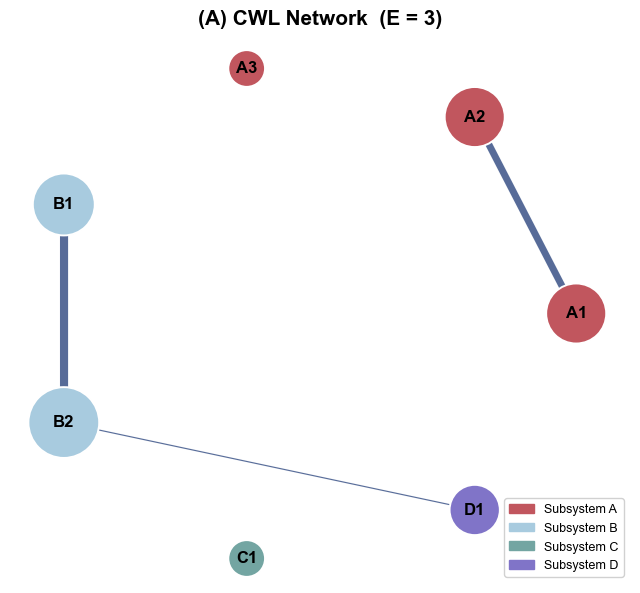

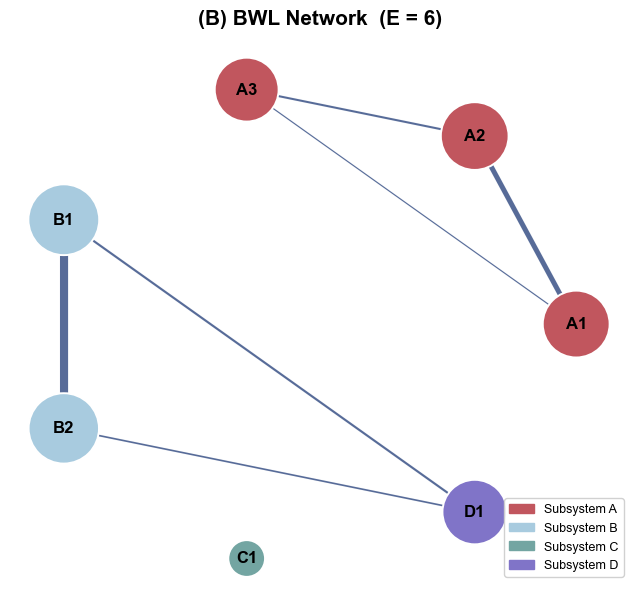

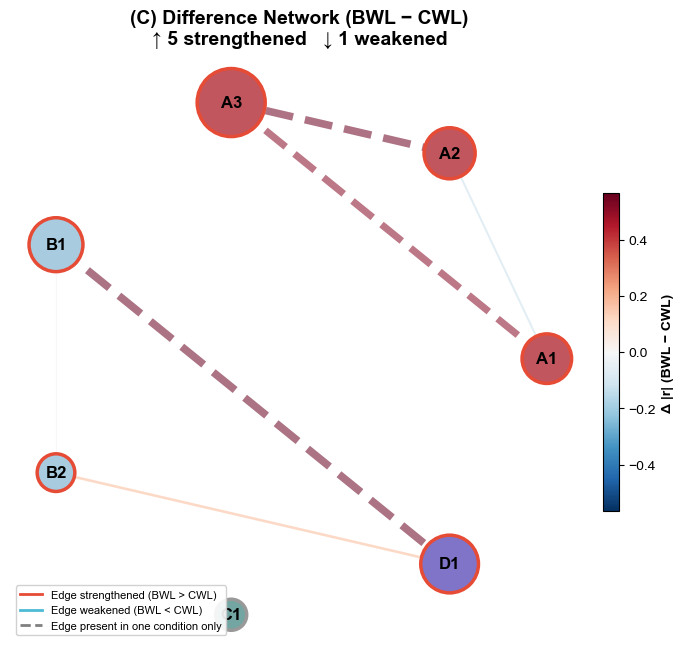

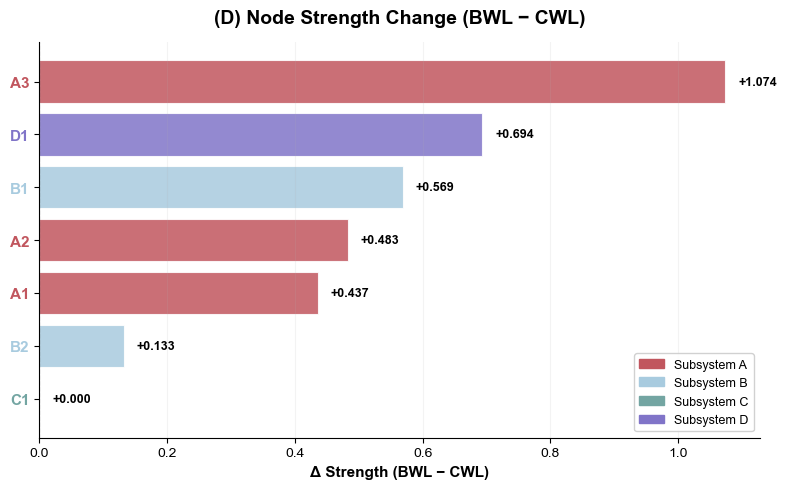

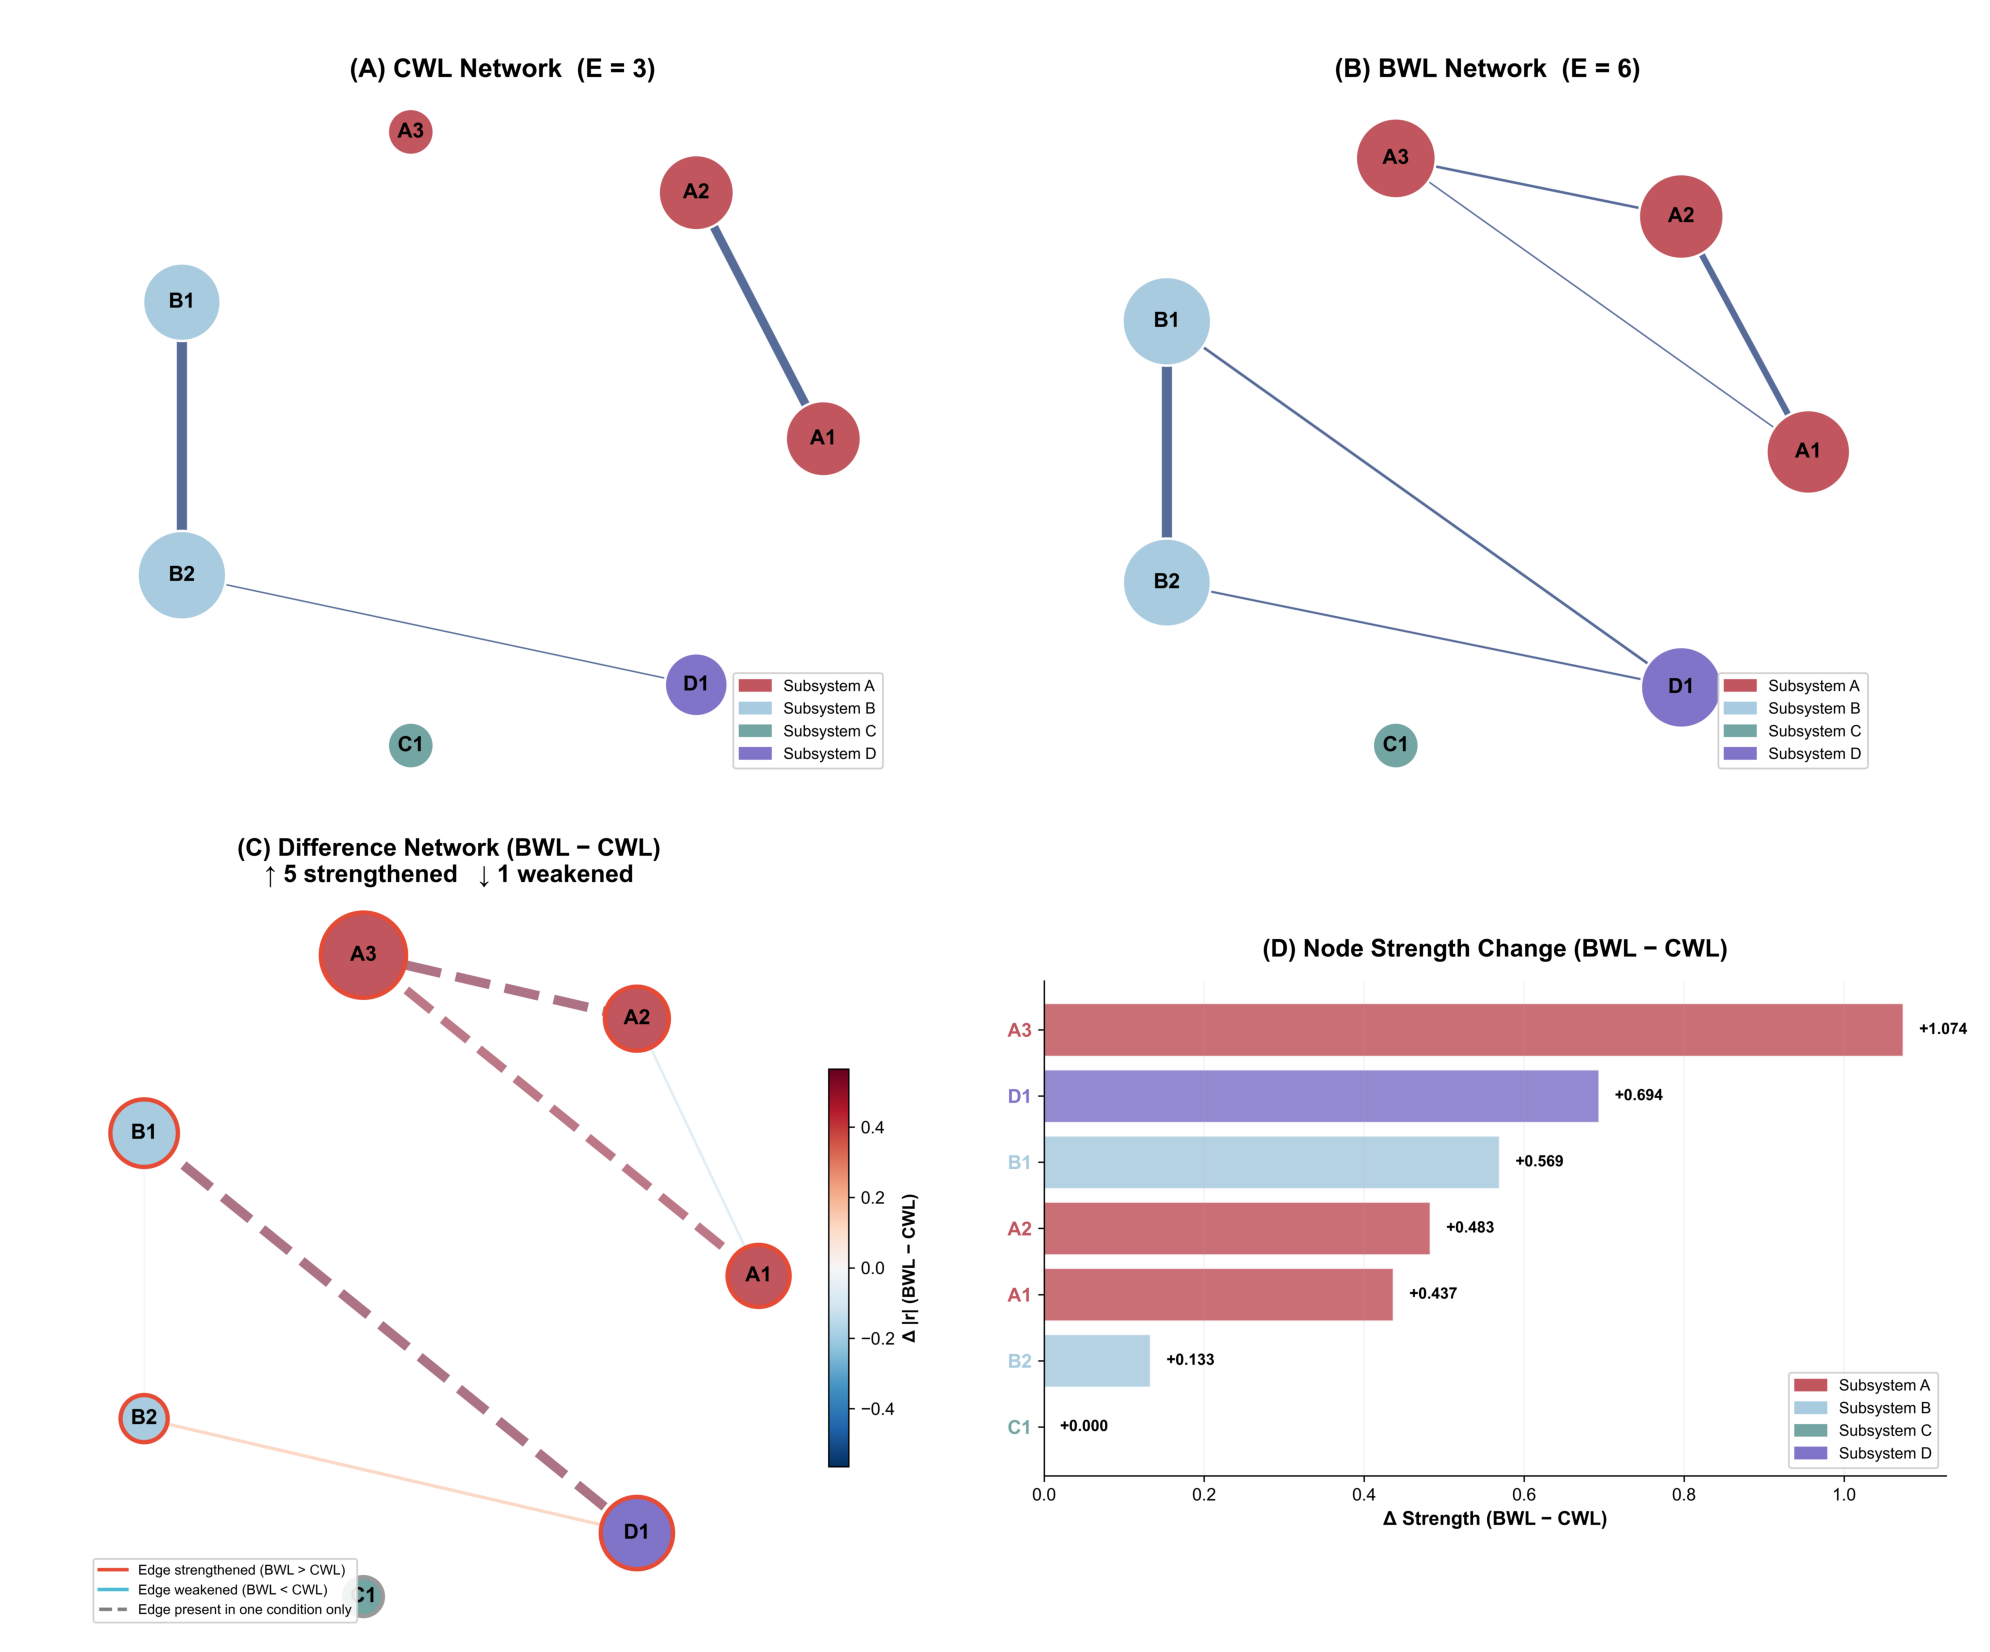

✅ Combined figure saved: output\figures\Fig1_combined_2x2.png
   Size: 9442 × 7824 px


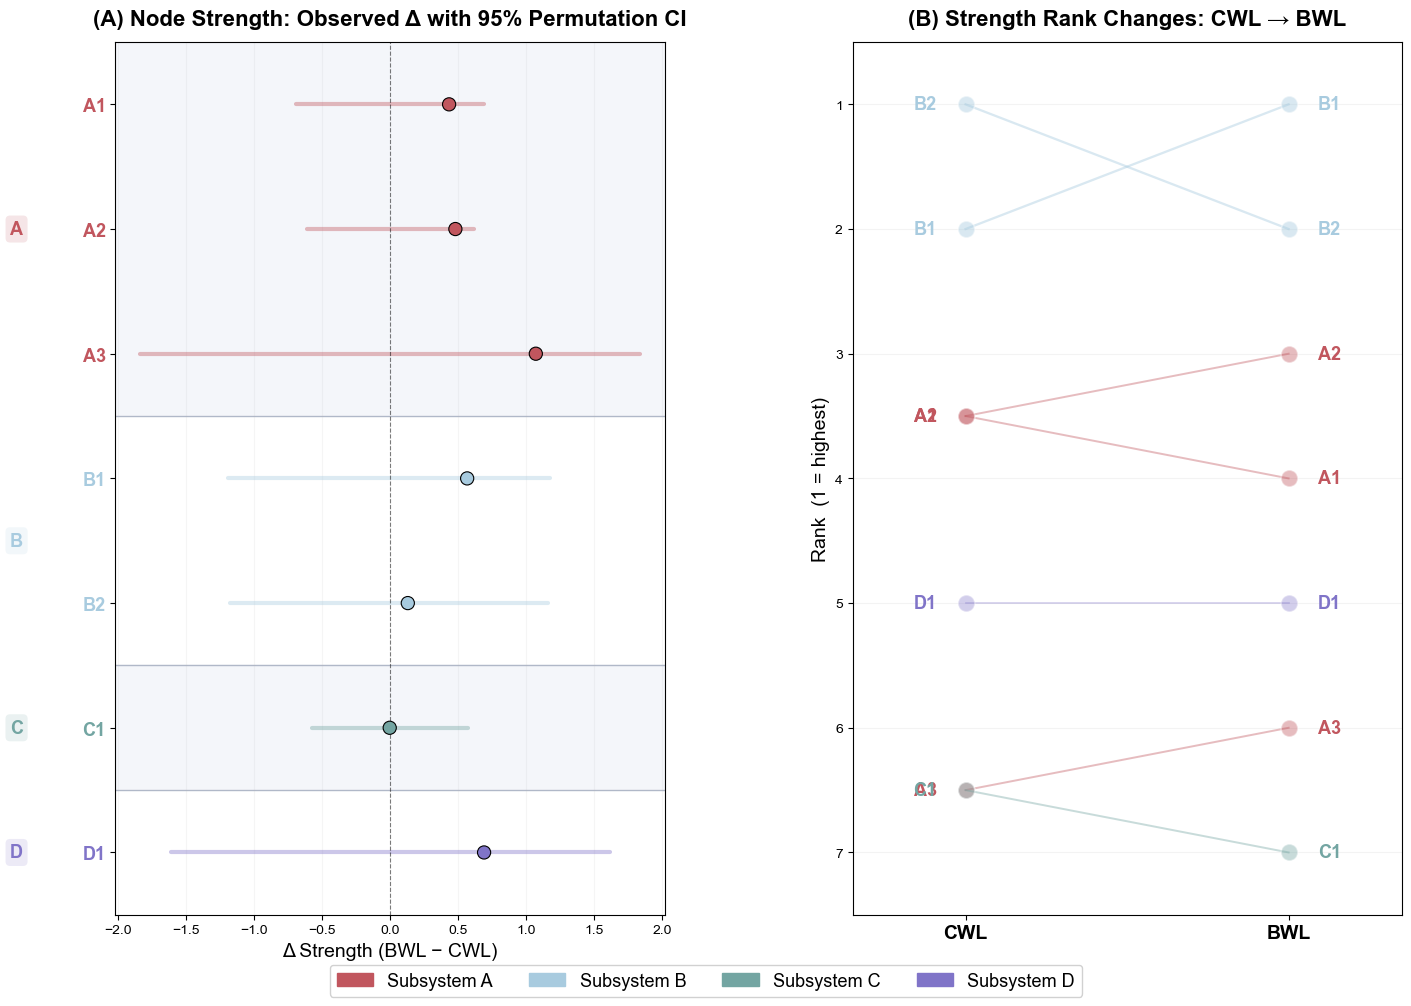

✅ Fig 2 saved: output\figures\Fig2_strength_forest_bump.png

📂 All figures saved to output\figures/


In [5]:
# ============================================================
#  Cell 5 — ALL FIGURES
# ============================================================

%matplotlib inline
plt.close("all")

# ── Shared helpers ─────────────────────────────────────────

def _scale(values, lo=NODE_SIZE_RANGE[0], hi=NODE_SIZE_RANGE[1]):
    a = np.asarray(values, dtype=float)
    if a.max() == a.min():
        return np.full_like(a, (lo + hi) / 2)
    return lo + (a - a.min()) * (hi - lo) / (a.max() - a.min())

SUB_LEG = [mpatches.Patch(color=SUBSYSTEM_COLORS[s], label=f"Subsystem {s}")
           for s in sorted(SUBSYSTEM_COLORS)]

fixed_pos = nx.circular_layout(NODE_COLS)


# ═══════════════════════════════════════════════════════════
#  Fig 1a / 1b — Condition Networks
# ═══════════════════════════════════════════════════════════

def plot_network(G, node_cols, strength, ax, title, pos):
    colors = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in node_cols]
    sizes  = _scale(strength.reindex(node_cols).fillna(0).values)
    edges  = list(G.edges(data=True))
    if edges:
        w = np.array([d["weight"] for _, _, d in edges])
        widths = EDGE_WIDTH_RANGE[0] + EDGE_WIDTH_RANGE[1] * (w - w.min()) / (w.max() - w.min() + 1e-12)
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               width=widths + 0.5,
                               edge_color=EDGE_HALO_COLOR, alpha=0.3)
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               width=widths,
                               edge_color=EDGE_COLOR, alpha=0.85)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_cols,
                           node_color=colors, node_size=sizes,
                           linewidths=1.4, edgecolors="white")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=12,
                            font_weight="bold", font_color="black")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.axis("off")


fig1a, ax = plt.subplots(figsize=(8, 7))
plot_network(obs_cwl["graph"], NODE_COLS, obs_cwl["strength"], ax,
             f"(A) {COND1_LABEL} Network  (E = {obs_cwl['graph'].number_of_edges()})",
             fixed_pos)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
fig1a.savefig(FIG_DIR / f"Fig1a_{COND1_LABEL}_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1a)

fig1b, ax = plt.subplots(figsize=(8, 7))
plot_network(obs_bwl["graph"], NODE_COLS, obs_bwl["strength"], ax,
             f"(B) {COND2_LABEL} Network  (E = {obs_bwl['graph'].number_of_edges()})",
             fixed_pos)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
fig1b.savefig(FIG_DIR / f"Fig1b_{COND2_LABEL}_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1b)


# ═══════════════════════════════════════════════════════════
#  Fig 1c — Difference Network
# ═══════════════════════════════════════════════════════════

def plot_difference_network(G_cwl, G_bwl, node_cols,
                            strength_cwl, strength_bwl, ax, pos):
    def _adj(G):
        d = {}
        for u, v, data in G.edges(data=True):
            w = data.get("weight", 0.0)
            d[tuple(sorted([u, v]))] = w if w is not None else 0.0
        return d

    adj1, adj2 = _adj(G_cwl), _adj(G_bwl)
    all_keys = set(adj1) | set(adj2)

    edge_data = []
    for key in all_keys:
        w1, w2 = adj1.get(key, 0.0), adj2.get(key, 0.0)
        diff = w2 - w1
        if abs(diff) > 1e-10:
            only_one = (w1 == 0.0 or w2 == 0.0)
            edge_data.append((key[0], key[1], diff, only_one))

    if not edge_data:
        ax.text(0.5, 0.5, "No edge differences",
                ha="center", va="center", fontsize=12,
                transform=ax.transAxes)
        ax.axis("off"); return

    diffs   = [d for _, _, d, _ in edge_data]
    abs_max = max(abs(d) for d in diffs)
    norm    = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    cmap    = plt.get_cmap("RdBu_r")

    for u, v, d, only_one in edge_data:
        color = cmap(norm(d))
        width = 0.8 + (abs(d) / (abs_max + 1e-12)) * 4.7
        style = "dashed" if only_one else "solid"
        alpha = 0.55 if only_one else 0.85
        G_tmp = nx.Graph(); G_tmp.add_edge(u, v)
        nx.draw_networkx_edges(G_tmp, pos, ax=ax, edgelist=[(u, v)],
                               width=width, edge_color=[color],
                               style=style, alpha=alpha)

    delta_s = (strength_bwl.reindex(node_cols).fillna(0) -
               strength_cwl.reindex(node_cols).fillna(0))
    node_sizes    = _scale(delta_s.abs().values, 500, 2400)
    face_colors   = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in node_cols]
    border_colors = ["#E64B35" if delta_s[n] > 0 else
                     "#4DBBD5" if delta_s[n] < 0 else
                     "#999999" for n in node_cols]

    G_h = nx.Graph(); G_h.add_nodes_from(node_cols)
    nx.draw_networkx_nodes(G_h, pos, ax=ax, nodelist=node_cols,
                           node_color=face_colors, node_size=node_sizes,
                           linewidths=2.5, edgecolors=border_colors)
    nx.draw_networkx_labels(G_h, pos, ax=ax, font_size=12,
                            font_weight="bold", font_color="black")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.55, aspect=20, pad=0.02)
    cbar.set_label(f"Δ |r| ({COND2_LABEL} − {COND1_LABEL})",
                   fontsize=10, fontweight="bold")

    n_up = sum(1 for _, _, d, _ in edge_data if d > 0)
    n_dn = sum(1 for _, _, d, _ in edge_data if d < 0)

    legend_elems = [
        Line2D([0], [0], color="#E64B35", lw=2,
               label=f"Edge strengthened ({COND2_LABEL} > {COND1_LABEL})"),
        Line2D([0], [0], color="#4DBBD5", lw=2,
               label=f"Edge weakened ({COND2_LABEL} < {COND1_LABEL})"),
        Line2D([0], [0], color="grey", lw=2, ls="dashed",
               label="Edge present in one condition only"),
    ]
    ax.legend(handles=legend_elems, loc="lower left", fontsize=8, framealpha=0.9)
    ax.set_title(f"(C) Difference Network ({COND2_LABEL} − {COND1_LABEL})\n"
                 f"↑ {n_up} strengthened   ↓ {n_dn} weakened",
                 fontsize=14, fontweight="bold", pad=14)
    ax.axis("off")


fig1c, ax = plt.subplots(figsize=(9, 7.5))
plot_difference_network(obs_cwl["graph"], obs_bwl["graph"], NODE_COLS,
                        obs_cwl["strength"], obs_bwl["strength"],
                        ax, fixed_pos)
fig1c.savefig(FIG_DIR / f"Fig1c_difference_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1c)


# ═══════════════════════════════════════════════════════════
#  Fig 1d — Strength Change Bar Chart
# ═══════════════════════════════════════════════════════════

def plot_strength_change_bar(strength_cwl, strength_bwl, node_cols, ax):
    delta_s = (strength_bwl.reindex(node_cols).fillna(0) -
               strength_cwl.reindex(node_cols).fillna(0))
    order = delta_s.sort_values(ascending=True).index
    delta_sorted = delta_s[order]
    colors = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in order]

    bars = ax.barh(range(len(order)), delta_sorted.values, color=colors,
                   edgecolor="white", linewidth=0.8, alpha=0.85)
    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_yticks(range(len(order)))
    ylabels = ax.set_yticklabels(order, fontsize=11, fontweight="bold")
    for lbl in ylabels:
        lbl.set_color(SUBSYSTEM_COLORS.get(lbl.get_text()[0], "#333"))

    for i, (val, bar) in enumerate(zip(delta_sorted.values, bars)):
        x_pos = max(val, 0) + 0.02
        ax.text(x_pos, i, f"{val:+.3f}", ha="left", va="center",
                fontsize=9, fontweight="bold")

    ax.set_xlabel(f"Δ Strength ({COND2_LABEL} − {COND1_LABEL})",
                  fontsize=11, fontweight="bold")
    ax.set_title(f"(D) Node Strength Change ({COND2_LABEL} − {COND1_LABEL})",
                 fontsize=14, fontweight="bold", pad=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.15)


fig1d, ax = plt.subplots(figsize=(8, 5))
plot_strength_change_bar(obs_cwl["strength"], obs_bwl["strength"], NODE_COLS, ax)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
fig1d.savefig(FIG_DIR / f"Fig1d_strength_change_bar.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1d)


# ═══════════════════════════════════════════════════════════
#  Fig 1 — Combined 2×2 Panel
# ═══════════════════════════════════════════════════════════

from PIL import Image

img_a = Image.open(FIG_DIR / f"Fig1a_{COND1_LABEL}_network.{FIG_FORMAT}")
img_b = Image.open(FIG_DIR / f"Fig1b_{COND2_LABEL}_network.{FIG_FORMAT}")
img_c = Image.open(FIG_DIR / f"Fig1c_difference_network.{FIG_FORMAT}")
img_d = Image.open(FIG_DIR / f"Fig1d_strength_change_bar.{FIG_FORMAT}")

max_w = max(img.width  for img in [img_a, img_b, img_c, img_d])
max_h = max(img.height for img in [img_a, img_b, img_c, img_d])

def pad_to(img, w, h):
    canvas = Image.new("RGB", (w, h), (255, 255, 255))
    x = (w - img.width)  // 2
    y = (h - img.height) // 2
    canvas.paste(img, (x, y))
    return canvas

img_a = pad_to(img_a, max_w, max_h)
img_b = pad_to(img_b, max_w, max_h)
img_c = pad_to(img_c, max_w, max_h)
img_d = pad_to(img_d, max_w, max_h)

combined = Image.new("RGB", (max_w * 2, max_h * 2), (255, 255, 255))
combined.paste(img_a, (0,      0))
combined.paste(img_b, (max_w,  0))
combined.paste(img_c, (0,      max_h))
combined.paste(img_d, (max_w,  max_h))

combined.save(FIG_DIR / f"Fig1_combined_2x2.{FIG_FORMAT}", dpi=(FIG_DPI, FIG_DPI))

fig, ax = plt.subplots(figsize=(20, 18))
ax.imshow(combined)
ax.axis("off")
plt.tight_layout()
plt.show()
plt.close()

print(f"✅ Combined figure saved: {FIG_DIR / f'Fig1_combined_2x2.{FIG_FORMAT}'}")
print(f"   Size: {combined.size[0]} × {combined.size[1]} px")


# ═══════════════════════════════════════════════════════════
#  Fig 2 — Combined: Forest Plot (A) + Bump Chart (B)
# ═══════════════════════════════════════════════════════════

sub_ids    = [n[0] for n in NODE_COLS]
boundaries = [i for i in range(1, len(sub_ids)) if sub_ids[i] != sub_ids[i - 1]]

ndf  = res["node_dfs"]["strength"]

fig2, (ax_forest, ax_bump) = plt.subplots(
    1, 2, figsize=(14, 10),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.20},
    constrained_layout=True
)

TITLE_FS   = 16
LABEL_FS   = 14
TICK_FS    = 13
NODE_LBL   = 13
MARKER_SZ  = 12

# ─── Panel (A): Forest Plot ───────────────────────────────

perm = res["perm_nm"]["strength"]
obs_diff = ndf["diff"].values
ci_lo    = np.percentile(perm, 2.5,  axis=0)
ci_hi    = np.percentile(perm, 97.5, axis=0)
y        = np.arange(len(NODE_COLS))
colors   = [SUBSYSTEM_COLORS.get(n[0], "#999") for n in NODE_COLS]

seg_starts = [0] + boundaries
seg_ends   = boundaries + [len(NODE_COLS)]
for k, (s, e) in enumerate(zip(seg_starts, seg_ends)):
    fc = "#F4F6FA" if k % 2 == 0 else "white"
    ax_forest.axhspan(s - 0.5, e - 0.5, color=fc, zorder=0)
for b in boundaries:
    ax_forest.axhline(b - 0.5, color="#B0B8C8", lw=1, ls="-", zorder=1)

for i in range(len(NODE_COLS)):
    ax_forest.plot([ci_lo[i], ci_hi[i]], [i, i],
                   color=colors[i], lw=3, alpha=0.4, solid_capstyle="round")
ax_forest.scatter(obs_diff, y, c=colors, s=90, zorder=5,
                  edgecolors="black", linewidths=0.8)
ax_forest.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax_forest.set_yticks(y)
ylabels = ax_forest.set_yticklabels(NODE_COLS, fontsize=TICK_FS, fontweight="bold")
for lbl in ylabels:
    lbl.set_color(SUBSYSTEM_COLORS.get(lbl.get_text()[0], "#333"))

for k, (s, e) in enumerate(zip(seg_starts, seg_ends)):
    mid = (s + e - 1) / 2.0
    letter = NODE_COLS[s][0]
    ax_forest.text(-0.18, mid, letter, fontsize=13, fontweight="bold",
                   color=SUBSYSTEM_COLORS.get(letter, "#333"),
                   ha="center", va="center",
                   transform=ax_forest.get_yaxis_transform(),
                   bbox=dict(boxstyle="round,pad=0.25",
                             fc=SUBSYSTEM_COLORS.get(letter, "#EEE"),
                             alpha=0.15, ec="none"))

ax_forest.invert_yaxis()
ax_forest.set_ylim(len(NODE_COLS) - 0.5, -0.5)
ax_forest.set_xlabel(f"Δ Strength ({COND2_LABEL} − {COND1_LABEL})",
                     fontsize=LABEL_FS)
ax_forest.set_title("(A) Node Strength: Observed Δ with 95% Permutation CI",
                     fontsize=TITLE_FS, fontweight="bold", pad=12)
ax_forest.grid(axis="x", alpha=0.12)

# ─── Panel (B): Bump Chart ────────────────────────────────

rank_c1 = ndf[COND1].rank(ascending=False).values.astype(float)
rank_c2 = ndf[COND2].rank(ascending=False).values.astype(float)

for i, node in enumerate(NODE_COLS):
    col  = SUBSYSTEM_COLORS.get(node[0], "#999")
    jump = abs(rank_c1[i] - rank_c2[i])
    lw   = 1.2 + jump * 0.45
    alph = 0.35 + min(jump / 12, 0.55)
    ax_bump.plot([0, 1], [rank_c1[i], rank_c2[i]], "o-",
                 color=col, lw=lw, alpha=alph, ms=MARKER_SZ,
                 markeredgecolor="white", markeredgewidth=1.2)
    ax_bump.text(-0.09, rank_c1[i], node, fontsize=NODE_LBL,
                 fontweight="bold", ha="right", va="center", color=col)
    ax_bump.text(1.09,  rank_c2[i], node, fontsize=NODE_LBL,
                 fontweight="bold", ha="left",  va="center", color=col)

ax_bump.set_xlim(-0.35, 1.35)
ax_bump.set_ylim(len(NODE_COLS) + 0.5, 0.5)
ax_bump.set_xticks([0, 1])
ax_bump.set_xticklabels([COND1_LABEL, COND2_LABEL],
                        fontsize=LABEL_FS, fontweight="bold")
ax_bump.set_ylabel("Rank  (1 = highest)", fontsize=LABEL_FS)
ax_bump.set_title(f"(B) Strength Rank Changes: {COND1_LABEL} → {COND2_LABEL}",
                   fontsize=TITLE_FS, fontweight="bold", pad=12)
ax_bump.grid(axis="y", alpha=0.15)

fig2.legend(handles=SUB_LEG, loc="outside lower center", ncol=len(SUB_LEG),
            fontsize=TICK_FS, framealpha=0.9)

fig2.savefig(FIG_DIR / f"Fig2_strength_forest_bump.{FIG_FORMAT}",
             dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig2)

print(f"✅ Fig 2 saved: {FIG_DIR / f'Fig2_strength_forest_bump.{FIG_FORMAT}'}")
print(f"\n📂 All figures saved to {FIG_DIR}/")

## Summary Tables & Data Export

In [6]:
# ============================================================
#  Cell 6 — SUMMARY TABLES & EXPORT
# ============================================================

print("📊 --- FIGURE DATA SUMMARY TABLES ---\n")

# Table 1: Node Strength + Univariate p (from original study)
df_nodes = res["node_dfs"]["strength"][["node", COND1, COND2, "diff", "p_perm"]].copy()
df_nodes.columns = ["Node", "Str_CWL", "Str_BWL", "Str_Diff", "Str_p_perm"]
df_nodes["Univariate_p"] = df_nodes["Node"].map(UNIVARIATE_P).fillna(1.0)

print("Table 1: Node Strength & Significance")
display(df_nodes.sort_values("Node").style.background_gradient(
    subset=["Str_Diff"], cmap="RdBu_r"))

# Table 2: Strength rank dynamics
df_ranks = pd.DataFrame({"Node": NODE_COLS})
df_ranks["Rank_CWL"] = res["node_dfs"]["strength"][COND1].rank(ascending=False).values
df_ranks["Rank_BWL"] = res["node_dfs"]["strength"][COND2].rank(ascending=False).values
df_ranks["Rank_Jump"] = (df_ranks["Rank_CWL"] - df_ranks["Rank_BWL"]).astype(int)

print("\nTable 2: Strength Rank Dynamics")
display(df_ranks.sort_values("Rank_BWL"))

# Table 3: Subsystem-grouped edge summary (§2.5.2)
print("\nTable 3: Subsystem-Grouped Edge Weight Changes (§2.5.2)")
display(sub_edge_summary)

# ── Export ───────────────────────────────────────────────
df_nodes.to_excel(TAB_DIR / "summary_node_strength.xlsx", index=False)
df_ranks.to_excel(TAB_DIR / "summary_rank_dynamics.xlsx", index=False)
sub_edge_summary.to_excel(TAB_DIR / "summary_subsystem_edge.xlsx", index=False)

print(f"\n📂 All tables saved to {TAB_DIR}/")
print(f"📂 All figures saved to {FIG_DIR}/")
print("\n✅ Analysis complete.")

📊 --- FIGURE DATA SUMMARY TABLES ---

Table 1: Node Strength & Significance


,Node,Str_CWL,Str_BWL,Str_Diff,Str_p_perm,Univariate_p
0,A1,0.790435,1.226957,0.436522,0.712029,0.588000
1,A2,0.790435,1.273043,0.482609,0.301970,0.050000
2,A3,0.000000,1.073913,1.073913,0.207679,0.263000
3,B1,0.871304,1.440558,0.569253,0.405159,0.035000
4,B2,1.283658,1.416639,0.132982,0.818918,0.024000
5,C1,0.000000,0.000000,0.000000,1.000000,0.004000
6,D1,0.412353,1.105893,0.693539,0.448455,0.000100



Table 2: Strength Rank Dynamics


,Node,Rank_CWL,Rank_BWL,Rank_Jump
3,B1,2.0,1.0,1
4,B2,1.0,2.0,-1
1,A2,3.5,3.0,0
0,A1,3.5,4.0,0
6,D1,5.0,5.0,0
2,A3,6.5,6.0,0
5,C1,6.5,7.0,0



Table 3: Subsystem-Grouped Edge Weight Changes (§2.5.2)


,subsystem_pair,n_edges,mean_delta,sd_delta
0,A–A,3,0.332174,0.355442
1,B–B,1,0.004348,0.000000
2,B–D,2,0.346770,0.308491



📂 All tables saved to output\tables/
📂 All figures saved to output\figures/

✅ Analysis complete.
